# Global GRU Baseline Pipeline

Two-stage workflow:

1. **Section 1 — Training** trains the Global GRU on `global_train` only and saves artifacts.
2. **Section 2 — Evaluation** loads saved artifacts and runs single-container demo inference only.

Evaluation philosophy:

- **Demo evaluation (Day 1):** temporal holdout on one container (`c_11461`) using `run_global_inference()`.
- **Multi-container cohort evaluation** is implemented in Phase 5 (`utils/global_evaluation.py`) and run via `scripts/run_global_gru_evaluation.py` — not in this notebook.

Set `RUN_TRAINING = False` in the configuration cell to skip training and evaluate a saved model.


## Shared Configuration


In [1]:
import importlib
import os
import pickle
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.append(os.path.abspath(".."))

# Reload utils after code changes (avoids stale Jupyter module cache).
import utils.global_artifacts as global_artifacts
import utils.global_config as global_config
import utils.global_inference as global_inference
import utils.global_training as global_training
import utils.hybrid_evaluation as hybrid_evaluation
import utils.sequence_utils as sequence_utils

importlib.reload(global_config)
importlib.reload(sequence_utils)
importlib.reload(global_training)
importlib.reload(global_inference)
importlib.reload(global_artifacts)
importlib.reload(hybrid_evaluation)

from utils.global_artifacts import (
    load_global_artifacts,
    save_global_artifacts,
)
from utils.global_config import (
    DEMO_CONTAINER_ID,
    FORECAST_HORIZON,
    INPUT_WINDOW,
    MAPE_EPSILON,
    RANDOM_SEED,
)
from utils.global_inference import run_global_inference
from utils.global_training import train_global_gru
from utils.hybrid_evaluation import (
    compute_day1_mape,
    compute_day1_metrics,
)

# Set False to skip Section 1 and load saved artifacts for evaluation only.
RUN_TRAINING = False

MODEL_PATH = "../models/global_gru.keras"
METADATA_PATH = "../models/global_gru_metadata.json"


Importing plotly failed. Interactive plots will not work.


## Shared Data Loading


In [2]:
train_df = pd.read_parquet("../data/train_df.parquet")
val_df = pd.read_parquet("../data/val_df.parquet")

with open("../data/scalers.pkl", "rb") as handle:
    scalers = pickle.load(handle)

selected_containers = np.load(
    "../data/selected_containers.npy",
    allow_pickle=True,
)
print(f"Selected containers: {len(selected_containers)}")

global_train = train_df[
    train_df["container_id"].isin(selected_containers)
].copy()

global_val = val_df[
    val_df["container_id"].isin(selected_containers)
].copy()


Selected containers: 100


---

# Section 1 — Global GRU Training

Trains Global GRU v1 on **train-period sequences only** (`global_train`) and saves:

- `../models/global_gru.keras`
- `../models/global_gru_metadata.json`

This section is skipped when `RUN_TRAINING = False`.


In [3]:
if RUN_TRAINING:
    global_gru_model, training_metadata = train_global_gru(
        global_train=global_train,
        input_window=INPUT_WINDOW,
        forecast_horizon=FORECAST_HORIZON,
        random_seed=RANDOM_SEED,
        verbose=1,
    )

    print("Training complete:")
    print(f"  Sequences      : {training_metadata['n_sequences']}")
    print(f"  Train / val    : {training_metadata['n_train_sequences']} / {training_metadata['n_val_sequences']}")
    print(f"  Epochs run     : {training_metadata['epochs_run']}")
    print(f"  Final val loss : {training_metadata['final_val_loss']}")


In [4]:
if RUN_TRAINING:
    saved_metadata = save_global_artifacts(
        model=global_gru_model,
        metadata=training_metadata,
        model_path=MODEL_PATH,
        metadata_path=METADATA_PATH,
    )

    print("Training artifacts saved:")
    print(f"  Model    : {MODEL_PATH}")
    print(f"  Metadata : {METADATA_PATH}")
    print(f"  Saved at : {saved_metadata['saved_at']}")


---

# Section 2 — Global GRU Evaluation (Demo Container)

Loads saved training artifacts and runs inference only.

**The GRU is never retrained in this section.**

Single-container Day 1 metrics (MAE, RMSE, MAPE) on the 96-step temporal holdout.

Full 99-container cohort evaluation is complete (Phase 5). Run `scripts/run_global_gru_evaluation.py` for cohort metrics; this notebook remains demo-only.


In [5]:
global_gru_model, artifact_metadata = load_global_artifacts(
    model_path=MODEL_PATH,
    metadata_path=METADATA_PATH,
)

artifact_input_window = int(
    artifact_metadata.get("input_window", INPUT_WINDOW)
)

if artifact_input_window != INPUT_WINDOW:
    print(
        f"Warning: notebook INPUT_WINDOW={INPUT_WINDOW} does not match "
        f"artifact input_window={artifact_input_window}. "
        "Evaluation will use the artifact value."
    )
    INPUT_WINDOW = artifact_input_window

print("Loaded training artifacts:")
print(f"  Model          : {MODEL_PATH}")
print(f"  Metadata       : {METADATA_PATH}")
print(f"  INPUT_WINDOW   : {INPUT_WINDOW}")
print(f"  Model variant  : {artifact_metadata.get('model_variant', 'unknown')}")
print(f"  Random seed    : {artifact_metadata.get('random_seed', 'unknown')}")


2026-07-17 13:19:24.379780: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2026-07-17 13:19:24.379858: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-07-17 13:19:24.379879: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-07-17 13:19:24.379917: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-07-17 13:19:24.379940: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Loaded training artifacts:
  Model          : ../models/global_gru.keras
  Metadata       : ../models/global_gru_metadata.json
  INPUT_WINDOW   : 96
  Model variant  : global_gru_v1
  Random seed    : 42


In [12]:
demo_container_id = DEMO_CONTAINER_ID

inference_result = run_global_inference(
    container_id=demo_container_id,
    global_train=global_train,
    global_val=global_val,
    model=global_gru_model,
    scalers=scalers,
    input_window=INPUT_WINDOW,
    forecast_horizon=FORECAST_HORIZON,
)

print(f"Demo container : {demo_container_id}")
print(f"Train steps    : {inference_result.n_train_steps}")
print(f"Val steps      : {inference_result.n_val_steps}")


Demo container : c_11461
Train steps    : 609
Val steps      : 153


In [15]:
global_mae, global_rmse = compute_day1_metrics(
    inference_result.actual_day1_real,
    inference_result.day1_pred_real,
)

global_mape = compute_day1_mape(
    inference_result.actual_day1_real,
    inference_result.day1_pred_real,
    epsilon=MAPE_EPSILON,
)

print(f"Container : {demo_container_id}")
print(f"MAE       : {global_mae:.4f}")
print(f"RMSE      : {global_rmse:.4f}")
print(f"MAPE      : {global_mape:.4f}")


Container : c_11461
MAE       : 2.7000
RMSE      : 3.4544
MAPE      : 25.8092


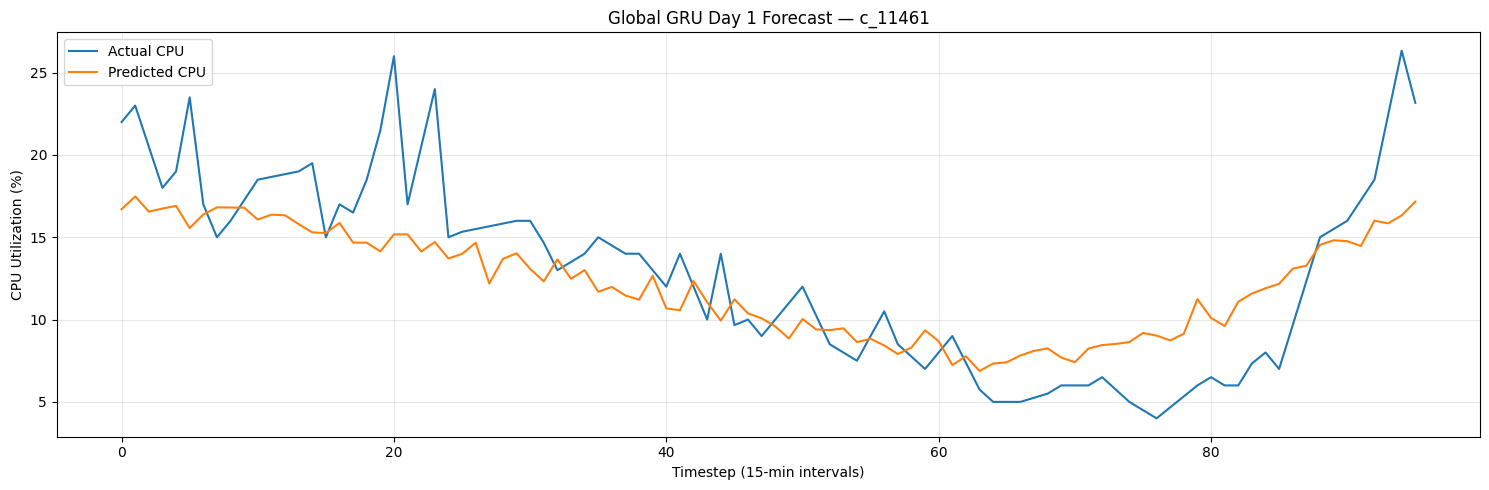

In [14]:
plt.figure(figsize=(15, 5))

plt.plot(
    inference_result.actual_day1_real,
    label="Actual CPU",
)

plt.plot(
    inference_result.day1_pred_real,
    label="Predicted CPU",
)

plt.title(
    f"Global GRU Day 1 Forecast — {demo_container_id}"
)
plt.xlabel("Timestep (15-min intervals)")
plt.ylabel("CPU Utilization (%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
